<a href="https://colab.research.google.com/github/chumba-dev/3D-image-effect/blob/main/ML_Cloud_Optimisation_Lab_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os

zip_file_path = '/content/Intelligent-Cloud-Resource-Optimization-System-main.zip'
extract_dir = '/content/'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' unzipped to '{extract_dir}' successfully!")


'/content/Intelligent-Cloud-Resource-Optimization-System-main.zip' unzipped to '/content/' successfully!


In [ ]:
import zipfile
import os

zip_file_path_2 = '/content/archive.zip'
extract_dir_2 = '/content/archive/'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir_2, exist_ok=True)

with zipfile.ZipFile(zip_file_path_2, 'r') as zip_ref:
    zip_ref.extractall(extract_dir_2)

print(f"'{zip_file_path_2}' unzipped to '{extract_dir_2}' successfully!")

BadZipFile: File is not a zip file

In [ ]:
import os

found_csv = False
for root, dirs, files in os.walk('/content/'):
    for name in files:
        if name == 'cloud_telemetry.csv':
            print(f"Found cloud_telemetry.csv at: {os.path.join(root, name)}")
            found_csv = True
            break
    if found_csv:
        break

if not found_csv:
    print("cloud_telemetry.csv not found in /content/ directory or its subdirectories.")

cloud_telemetry.csv not found in /content/ directory or its subdirectories.


In [ ]:
import os

found_csv = False
search_path = '/content/Intelligent-Cloud-Resource-Optimization-System-main/'

for root, dirs, files in os.walk(search_path):
    for name in files:
        if name == 'cloud_telemetry.csv':
            print(f"Found cloud_telemetry.csv at: {os.path.join(root, name)}")
            found_csv = True
            break
    if found_csv:
        break

if not found_csv:
    print(f"cloud_telemetry.csv not found in {search_path} or its subdirectories.")

cloud_telemetry.csv not found in /content/Intelligent-Cloud-Resource-Optimization-System-main/ or its subdirectories.


In [ ]:
import os

print("Listing all files and directories under /content/:")
for root, dirs, files in os.walk('/content/'):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Listing all files and directories under /content/:
/content/Intelligent-Cloud-Resource-Optimization-System-main.zip
/content/archive.zip
/content/.config
/content/archive
/content/Intelligent-Cloud-Resource-Optimization-System-main
/content/sample_data
/content/.config/active_config
/content/.config/.last_opt_in_prompt.yaml
/content/.config/config_sentinel
/content/.config/.last_survey_prompt.yaml
/content/.config/gce
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/.last_update_check.json
/content/.config/default_configs.db
/content/.config/configurations
/content/.config/logs
/content/.config/configurations/config_default
/content/.config/logs/2026.08.10
/content/.config/logs/2026.08.10/13.25.25.328016.log
/content/.config/logs/2026.08.10/13.26.18.998373.log
/content/.config/logs/2026.08.10/13.26.03.888211.log
/content/.config/logs/2026.08.10/13.25.43.233148.log
/content/.config/logs/2026.08.10/13.26.19.834999.log
/content/.config/logs/

**Cell 1: Environment Setup & Data Generation/Loading**

In [ ]:
# -------------------- Outcome 1: EDA & Setup --------------------
# 1. Install any missing packages
!pip install -q gymnasium numpy pandas matplotlib seaborn scikit-learn tensorflow

# 2. Imports & Seed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, json, gymnasium as gym
from gymnasium import spaces
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error,
                             accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, mean_absolute_percentage_error)
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from collections import deque
import random
import tensorflow as tf
from tensorflow.keras import layers, Model

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# 3. Create directory for outputs
os.makedirs("outputs", exist_ok=True)

# 4. Load dataset (or generate a synthetic one if not found)
dataset_path = "cloud_telemetry.csv"
if os.path.exists(dataset_path):
    df = pd.read_csv(dataset_path)
    print("Dataset loaded from file.")
else:
    print("No dataset found – generating synthetic 10,000 row cloud telemetry data.")
    n_samples = 10000
    np.random.seed(SEED)
    cpu = np.random.uniform(10, 100, n_samples)
    mem = np.random.uniform(20, 90, n_samples)
    disk = np.random.uniform(0, 500, n_samples)
    net_in = np.random.uniform(0, 1000, n_samples)
    net_out = np.random.uniform(0, 1000, n_samples)
    req_rate = np.random.poisson(lam=50, size=n_samples) + cpu * 0.3
    response_time = 0.5 * cpu + 0.2 * mem + 0.1 * req_rate + np.random.normal(0, 5, n_samples)
    failure_prob = 1 / (1 + np.exp(-(cpu - 70) / 10))  # more failures when CPU high
    failure = (np.random.rand(n_samples) < failure_prob).astype(int)
    df = pd.DataFrame({
        'timestamp': pd.date_range('2025-01-01', periods=n_samples, freq='min'),
        'cpu_usage': cpu,
        'memory_usage': mem,
        'disk_io': disk,
        'network_in': net_in,
        'network_out': net_out,
        'request_rate': req_rate,
        'response_time': response_time,
        'failure': failure
    })
    df.to_csv(dataset_path, index=False)
    print(f"Synthetic dataset saved as {dataset_path}")

df.head()

No dataset found – generating synthetic 10,000 row cloud telemetry data.
Synthetic dataset saved as cloud_telemetry.csv


,timestamp,cpu_usage,memory_usage,disk_io,network_in,network_out,request_rate,response_time,failure
0,2025-01-01 00:00:00,43.708611,46.154857,364.999155,638.144568,298.912041,71.112583,28.101276,0
1,2025-01-01 00:01:00,95.564288,43.303847,92.255998,459.292454,94.817775,71.669286,60.224839,1
2,2025-01-01 00:02:00,75.879455,32.330774,173.319847,964.498525,126.359225,70.763836,44.984470,1
3,2025-01-01 00:03:00,63.879264,62.508667,331.640318,218.978451,180.671128,59.163779,39.079698,0
4,2025-01-01 00:04:00,24.041678,53.363691,241.044672,587.856416,203.653334,54.212503,31.827453,0


**Cell 2: Descriptive Statistics & Visualisations**

=== Descriptive Statistics ===


,timestamp,cpu_usage,memory_usage,disk_io,network_in,network_out,request_rate,response_time,failure
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2025-01-04 11:19:30,54.474360,55.317091,250.025197,498.713383,496.863806,66.451208,45.027421,0.331600
min,2025-01-01 00:00:00,10.001047,20.011042,0.024062,0.005537,0.016736,28.990129,4.304794,0.000000
25%,2025-01-02 17:39:45,32.169598,37.776206,126.873956,246.857249,244.272222,58.868087,33.009859,0.000000
50%,2025-01-04 11:19:30,54.327576,55.412774,251.034047,500.030239,493.717192,66.475330,44.885996,0.000000
75%,2025-01-06 04:59:15,76.600571,72.953545,372.336927,747.116254,750.477034,74.045711,56.985404,1.000000
max,2025-01-07 22:39:00,99.974591,89.994738,499.950489,999.789372,999.972147,112.970427,90.348418,1.000000
std,NaN,25.886711,20.250619,143.386879,288.994591,289.284179,10.529505,15.149686,0.470812


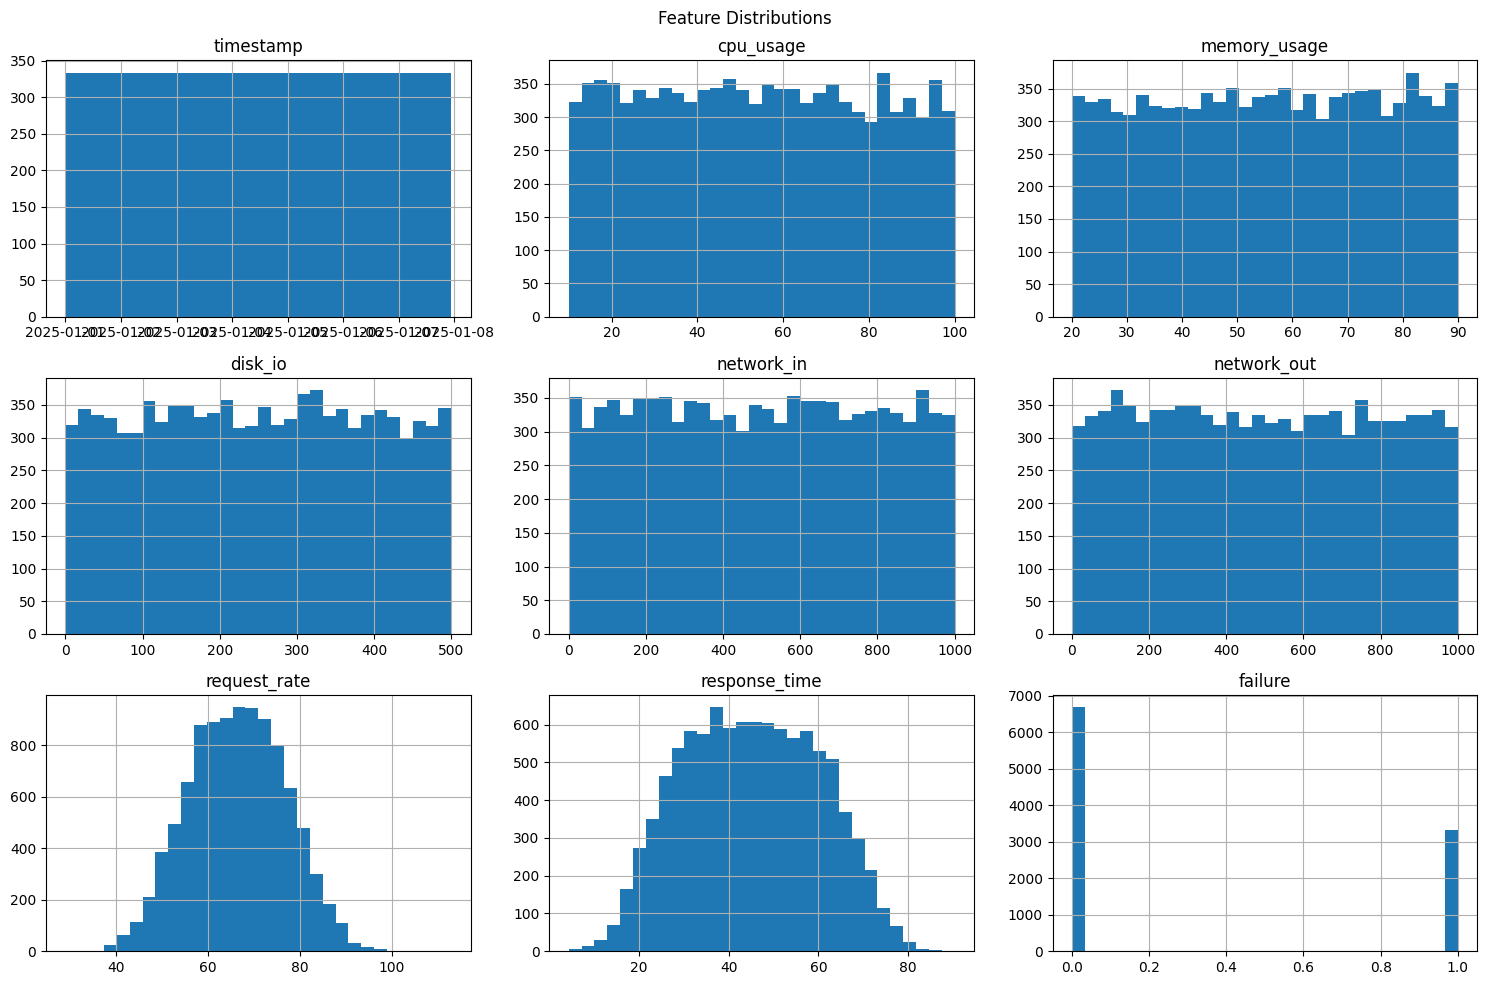

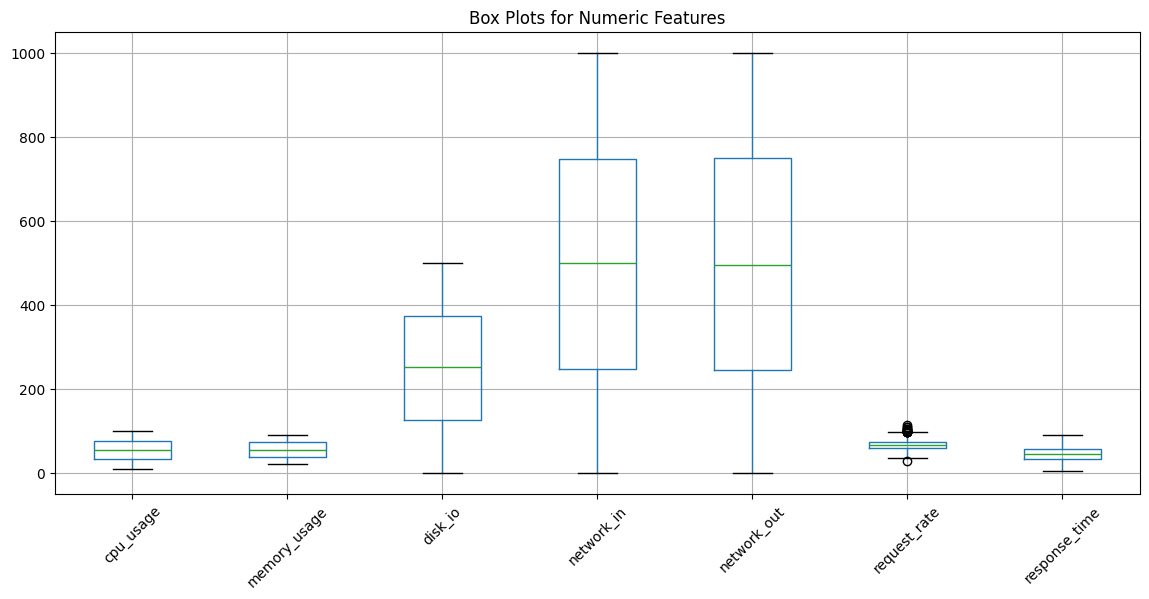

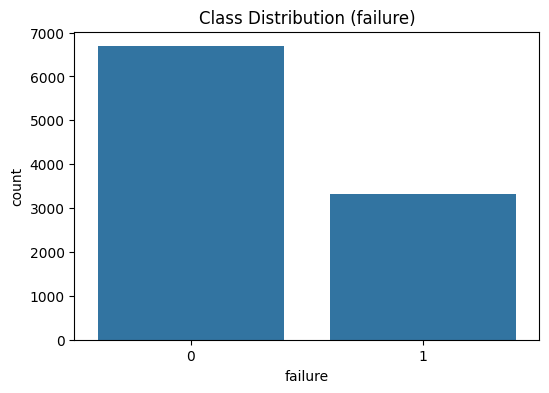

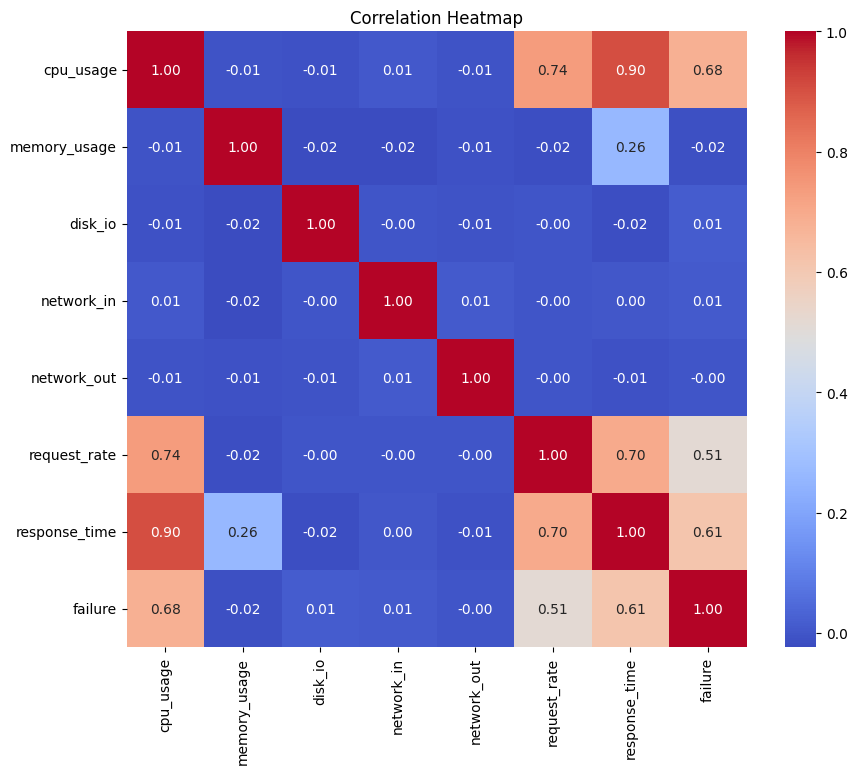

Multicollinear features flagged: [('cpu_usage', 'response_time'), ('response_time', 'cpu_usage')]
cpu_usage outliers: 0
memory_usage outliers: 0
response_time outliers: 0


In [ ]:
# Descriptive statistics
print("=== Descriptive Statistics ===")
display(df.describe())

# Histograms of numeric features
df.hist(bins=30, figsize=(15,10))
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.savefig("outputs/histograms.png")
plt.show()

# Box plots to spot outliers
plt.figure(figsize=(14,6))
df.drop(columns=['timestamp','failure']).boxplot(rot=45)
plt.title("Box Plots for Numeric Features")
plt.savefig("outputs/boxplots.png")
plt.show()

# Class distribution (for classification target)
plt.figure(figsize=(6,4))
sns.countplot(x='failure', data=df)
plt.title("Class Distribution (failure)")
plt.savefig("outputs/class_distribution.png")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
corr = df.drop(columns=['timestamp']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig("outputs/correlation_heatmap.png")
plt.show()

# Identify multicollinear pairs (corr > 0.9 or < -0.9)
high_corr_pairs = [(i, j) for i in corr.columns for j in corr.columns if i!=j and abs(corr.loc[i,j]) > 0.9]
if high_corr_pairs:
    print("Multicollinear features flagged:", high_corr_pairs)
else:
    print("No multicollinear features above 0.9 threshold.")

# Outlier detection (IQR method) for a few features
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return len(outliers)

for col in ['cpu_usage', 'memory_usage', 'response_time']:
    print(f"{col} outliers: {detect_outliers(df, col)}")

**Cell 3: Supervised Learning – Regression Models**

In [ ]:
# -------------------- Outcome 2: Regression --------------------
# Features and target for regression
reg_target = 'response_time'
reg_features = ['cpu_usage', 'memory_usage', 'disk_io', 'network_in', 'network_out', 'request_rate']
X_reg = df[reg_features]
y_reg = df[reg_target]

# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=SEED)

# Scaling (fit only on training)
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

# Define models
reg_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1, max_iter=10000),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=SEED),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=SEED)
}

# Train and evaluate
reg_results = {}
for name, model in reg_models.items():
    model.fit(X_train_r_scaled, y_train_r)
    y_pred = model.predict(X_test_r_scaled)
    r2 = r2_score(y_test_r, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    mae = mean_absolute_error(y_test_r, y_pred)
    mape = mean_absolute_percentage_error(y_test_r, y_pred) * 100
    reg_results[name] = {'R²': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    print(f"{name}: R²={r2:.3f}, RMSE={rmse:.3f}, MAE={mae:.3f}, MAPE={mape:.2f}%")

# 5-fold cross-validation on best model (choose based on R²)
best_r_name = max(reg_results, key=lambda x: reg_results[x]['R²'])
best_r_model = reg_models[best_r_name]
cv_scores = cross_val_score(best_r_model, scaler_r.transform(X_reg), y_reg, cv=5, scoring='r2')
print(f"\nBest Regression Model: {best_r_name}")
print(f"5-fold CV R²: mean={cv_scores.mean():.3f}, std={cv_scores.std():.3f}")

Linear Regression: R²=0.890, RMSE=4.977, MAE=3.977, MAPE=10.25%
Ridge: R²=0.890, RMSE=4.977, MAE=3.977, MAPE=10.25%
Lasso: R²=0.890, RMSE=4.974, MAE=3.975, MAPE=10.27%
Random Forest: R²=0.880, RMSE=5.209, MAE=4.172, MAPE=10.75%
Gradient Boosting: R²=0.888, RMSE=5.037, MAE=4.024, MAPE=10.39%

Best Regression Model: Lasso
5-fold CV R²: mean=0.891, std=0.004


**Cell 4: Overfitting Gap & Regularisation Discussion**

In [ ]:
# Overfitting gap (train vs test R²) for Random Forest as an example
model_rf = RandomForestRegressor(n_estimators=100, random_state=SEED)
model_rf.fit(X_train_r_scaled, y_train_r)
y_train_pred = model_rf.predict(X_train_r_scaled)
y_test_pred = model_rf.predict(X_test_r_scaled)
r2_train = r2_score(y_train_r, y_train_pred)
r2_test = r2_score(y_test_r, y_test_pred)
print(f"Random Forest Train R² = {r2_train:.3f}, Test R² = {r2_test:.3f}")
print(f"Overfitting gap = {r2_train - r2_test:.3f}")

# Compare with Ridge (regularized)
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train_r_scaled, y_train_r)
r2_ridge_train = r2_score(y_train_r, model_ridge.predict(X_train_r_scaled))
r2_ridge_test = r2_score(y_test_r, model_ridge.predict(X_test_r_scaled))
print(f"Ridge Train R² = {r2_ridge_train:.3f}, Test R² = {r2_ridge_test:.3f}")
print("Regularization (Ridge) reduces overfitting gap compared to unregularized models.")

Random Forest Train R² = 0.984, Test R² = 0.880
Overfitting gap = 0.104
Ridge Train R² = 0.892, Test R² = 0.890
Regularization (Ridge) reduces overfitting gap compared to unregularized models.


**Cell 5: Classification Models**

In [ ]:
# -------------------- Outcome 2: Classification --------------------
clf_target = 'failure'
X_clf = df[reg_features]  # same features
y_clf = df[clf_target]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

clf_models = {
    'Logistic Regression': LogisticRegression(random_state=SEED, max_iter=1000),
    'SVM': SVC(probability=True, random_state=SEED),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=SEED)
}

clf_results = {}
for name, model in clf_models.items():
    model.fit(X_train_c_scaled, y_train_c)
    y_pred = model.predict(X_test_c_scaled)
    y_proba = model.predict_proba(X_test_c_scaled)[:,1] if hasattr(model, "predict_proba") else None
    acc = accuracy_score(y_test_c, y_pred)
    f1 = f1_score(y_test_c, y_pred)
    prec = precision_score(y_test_c, y_pred)
    rec = recall_score(y_test_c, y_pred)
    auc = roc_auc_score(y_test_c, y_proba) if y_proba is not None else None
    clf_results[name] = {'Accuracy': acc, 'F1': f1, 'Precision': prec, 'Recall': rec, 'AUC-ROC': auc}
    print(f"{name}: Acc={acc:.3f}, F1={f1:.3f}, Prec={prec:.3f}, Rec={rec:.3f}, AUC={auc:.3f}" if auc else "AUC N/A")

# Best classifier based on F1
best_c_name = max(clf_results, key=lambda x: clf_results[x]['F1'])
best_c_model = clf_models[best_c_name]
cv_f1 = cross_val_score(best_c_model, scaler_c.transform(X_clf), y_clf, cv=5, scoring='f1')
print(f"\nBest Classification Model: {best_c_name}")
print(f"5-fold CV F1: mean={cv_f1.mean():.3f}, std={cv_f1.std():.3f}")

Logistic Regression: Acc=0.850, F1=0.769, Prec=0.784, Rec=0.754, AUC=0.924
SVM: Acc=0.853, F1=0.773, Prec=0.791, Rec=0.756, AUC=0.908
KNN: Acc=0.829, F1=0.737, Prec=0.749, Rec=0.725, AUC=0.878
Random Forest: Acc=0.844, F1=0.760, Prec=0.776, Rec=0.744, AUC=0.913
Gradient Boosting: Acc=0.851, F1=0.773, Prec=0.780, Rec=0.766, AUC=0.923

Best Classification Model: Gradient Boosting
5-fold CV F1: mean=0.764, std=0.009


**Cell 6: Unsupervised Clustering & Dimensionality Reduction**

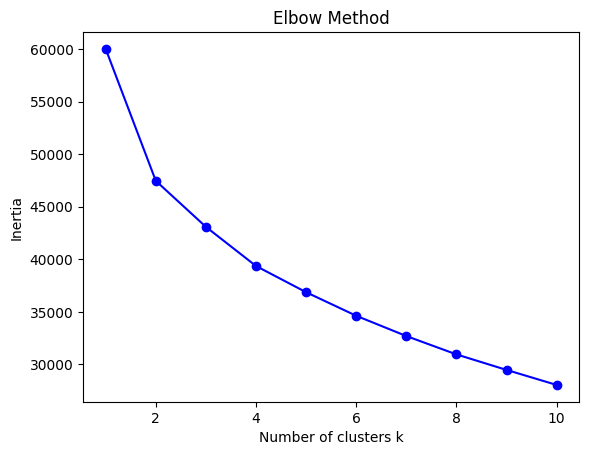

Optimal K from silhouette: 2
KMeans: Silhouette=0.190, DB=1.902, CH=2642.169
DBSCAN: Silhouette=nan, DB=nan, CH=nan (may be nan if all noise)
Agglomerative: Silhouette=0.146, DB=2.222, CH=1927.708


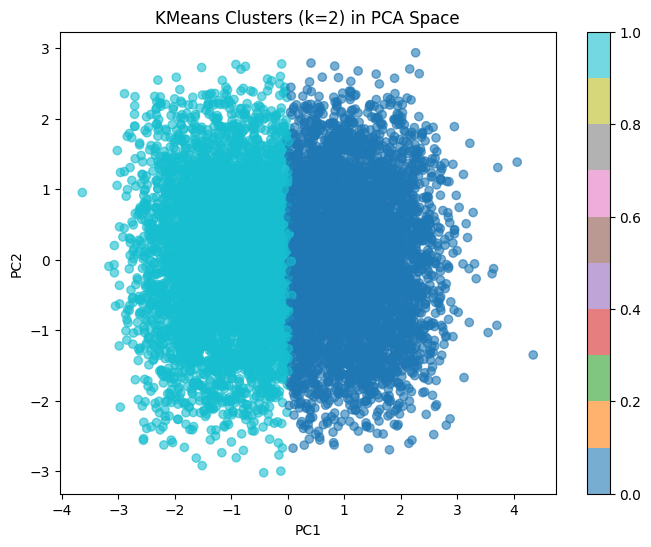

PCA explained variance: [0.28982323 0.17223412]


In [ ]:
# -------------------- Outcome 3: Clustering --------------------
# Use all features except timestamp and targets
cluster_features = [c for c in df.columns if c not in ['timestamp','failure','response_time']]
X_clust = df[cluster_features]

# Scale
scaler_clust = StandardScaler()
X_clust_scaled = scaler_clust.fit_transform(X_clust)

# Elbow method for KMeans
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_clust_scaled)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.savefig("outputs/elbow.png")
plt.show()

# Silhouette sweep for k=2..10
sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_clust_scaled)
    sil_scores.append(silhouette_score(X_clust_scaled, labels))
opt_k = range(2,11)[np.argmax(sil_scores)]
print(f"Optimal K from silhouette: {opt_k}")

# Apply at least 2 clustering algorithms
# KMeans
kmeans = KMeans(n_clusters=opt_k, random_state=SEED, n_init=10)
labels_kmeans = kmeans.fit_predict(X_clust_scaled)
# DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=10)
labels_dbscan = dbscan.fit_predict(X_clust_scaled)
# Agglomerative
agg = AgglomerativeClustering(n_clusters=opt_k)
labels_agg = agg.fit_predict(X_clust_scaled)

# Cluster evaluation metrics
def cluster_metrics(X, labels):
    # ignore noise label -1 for DBSCAN
    if len(set(labels)) > 1 and -1 not in labels:
        sil = silhouette_score(X, labels)
        db = davies_bouldin_score(X, labels)
        ch = calinski_harabasz_score(X, labels)
        return sil, db, ch
    else:
        return np.nan, np.nan, np.nan

k_sil, k_db, k_ch = cluster_metrics(X_clust_scaled, labels_kmeans)
d_sil, d_db, d_ch = cluster_metrics(X_clust_scaled, labels_dbscan)
a_sil, a_db, a_ch = cluster_metrics(X_clust_scaled, labels_agg)

print(f"KMeans: Silhouette={k_sil:.3f}, DB={k_db:.3f}, CH={k_ch:.3f}")
print(f"DBSCAN: Silhouette={d_sil}, DB={d_db}, CH={d_ch} (may be nan if all noise)")
print(f"Agglomerative: Silhouette={a_sil:.3f}, DB={a_db:.3f}, CH={a_ch:.3f}")

# PCA to 2D for visualisation
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_clust_scaled)

# Plot KMeans clusters in PCA space
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_kmeans, cmap='tab10', alpha=0.6)
plt.colorbar(scatter)
plt.title(f'KMeans Clusters (k={opt_k}) in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.savefig("outputs/clusters_pca.png")
plt.show()

print(f"PCA explained variance: {pca.explained_variance_ratio_}")

**Cell 7: Reinforcement Learning Environment (MDP)**

In [ ]:
# -------------------- Outcome 4: RL Environment --------------------
# Define a Cloud Scheduling Environment as an MDP
# State: [cpu_usage, memory_usage, request_rate, current_capacity]
# Action: 0 = keep, 1 = scale up (+10%), 2 = scale down (-10%)
# Reward: - (SLA_violation_cost + capacity_cost)
# SLA violation if demand > capacity.

class CloudEnv(gym.Env):
    def __init__(self, data_df, window=1):
        super().__init__()
        self.data = data_df[['cpu_usage', 'memory_usage', 'request_rate']].values
        self.n_steps = len(self.data) - window
        self.current_step = 0
        self.capacity = 100.0  # initial total resource capacity
        self.min_cap = 50.0
        self.max_cap = 200.0
        self.window = window

        # Action space: 0=keep, 1=scale up, 2=scale down
        self.action_space = spaces.Discrete(3)
        # State space: [cpu, mem, req_rate, capacity] all normalized
        self.observation_space = spaces.Box(low=0, high=1, shape=(4,), dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = random.randint(0, self.n_steps-1)
        self.capacity = 100.0
        return self._get_state(), {}

    def _get_state(self):
        cpu, mem, req = self.data[self.current_step]
        state = np.array([cpu/100, mem/100, req/200, self.capacity/200], dtype=np.float32)
        return state

    def step(self, action):
        # Apply action
        if action == 1:
            self.capacity = min(self.max_cap, self.capacity + 10)
        elif action == 2:
            self.capacity = max(self.min_cap, self.capacity - 10)

        # Fetch current demand
        cpu, mem, req = self.data[self.current_step]
        demand = cpu * 0.5 + mem * 0.3 + req * 0.2  # weighted sum as resource demand

        # Reward: SLA violation penalty if demand > capacity, plus capacity cost
        sla_violation = 1 if demand > self.capacity else 0
        reward = -10 * sla_violation - 0.01 * self.capacity  # heavy penalty for SLA violation

        # Move to next step
        self.current_step = (self.current_step + 1) % self.n_steps
        terminated = False  # continuous task
        truncated = False
        return self._get_state(), reward, terminated, truncated, {}

    def render(self):
        pass

# Instantiate environment
env = CloudEnv(df)
print("State sample:", env.reset()[0])

State sample: [0.6795138 0.7725402 0.3969271 0.5      ]


**Cell 8: Q-Learning Agent (tabular)**

In [ ]:
# Discretize continuous state for Q-table
def discretize_state(state, bins=(10,10,10,10)):
    # state is already [0,1]
    idx = []
    for i, val in enumerate(state):
        idx.append(min(bins[i]-1, int(val * bins[i])))
    return tuple(idx)

# Q-Learning training
q_table = np.zeros((10,10,10,10,3))  # state bins x actions
alpha = 0.1
gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.995
min_eps = 0.01
episodes = 200

ep_rewards_ql = []
sla_violations_ql = []

for ep in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    sla_count = 0
    done = False
    for t in range(200):  # steps per episode
        s_disc = discretize_state(state)
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[s_disc])
        next_state, reward, _, _, _ = env.step(action)
        ns_disc = discretize_state(next_state)
        # update Q
        q_table[s_disc][action] += alpha * (reward + gamma * np.max(q_table[ns_disc]) - q_table[s_disc][action])
        state = next_state
        total_reward += reward
        if reward == -10:  # SLA violation
            sla_count += 1
    ep_rewards_ql.append(total_reward)
    sla_violations_ql.append(sla_count / 200)  # violation rate
    epsilon = max(min_eps, epsilon * epsilon_decay)

print(f"Q-Learning: Avg reward last 20 eps = {np.mean(ep_rewards_ql[-20:]):.2f}")
print(f"Q-Learning: Avg SLA violation rate last 20 eps = {np.mean(sla_violations_ql[-20:]):.4f} ({np.mean(sla_violations_ql[-20:])*100:.2f}%)")

Q-Learning: Avg reward last 20 eps = -283.12
Q-Learning: Avg SLA violation rate last 20 eps = 0.0000 (0.00%)


**Cell 9: DQN Agent**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from collections import deque
# DQN Agent
class DQN:
    def __init__(self, state_dim, action_dim, lr=0.001):
        self.action_dim = action_dim
        self.model = self.build_model(state_dim, action_dim, lr)
        self.target_model = self.build_model(state_dim, action_dim, lr)
        self.update_target()
        self.memory = deque(maxlen=2000)
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.batch_size = 64

    def build_model(self, state_dim, action_dim, lr):
        input_layer = layers.Input(shape=(state_dim,))
        x = layers.Dense(64, activation='relu')(input_layer)
        x = layers.Dense(64, activation='relu')(x)
        output = layers.Dense(action_dim, activation='linear')(x)
        model = Model(inputs=input_layer, outputs=output)
        model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=lr))
        return model

    def update_target(self):
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_dim)
        q_values = self.model.predict(state[np.newaxis,:], verbose=0)
        return np.argmax(q_values[0])

    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        minibatch = random.sample(self.memory, self.batch_size)
        states = np.array([s for (s,a,r,s2,d) in minibatch])
        next_states = np.array([s2 for (s,a,r,s2,d) in minibatch])
        targets = self.model.predict(states, verbose=0)
        next_targets = self.target_model.predict(next_states, verbose=0)
        for i, (state, action, reward, next_state, done) in enumerate(minibatch):
            if done:
                targets[i][action] = reward
            else:
                targets[i][action] = reward + self.gamma * np.max(next_targets[i])
        self.model.fit(states, targets, epochs=1, verbose=0)
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

state_dim = 4
action_dim = 3
dqn_agent = DQN(state_dim, action_dim)
episodes_dqn = 200
ep_rewards_dqn = []
sla_violations_dqn = []

for ep in range(episodes_dqn):
    state, _ = env.reset()
    total_reward = 0
    sla_count = 0
    for t in range(200):
        action = dqn_agent.act(state)
        next_state, reward, _, _, _ = env.step(action)
        dqn_agent.remember(state, action, reward, next_state, False)
        state = next_state
        total_reward += reward
        if reward == -10:
            sla_count += 1
        dqn_agent.replay()
    ep_rewards_dqn.append(total_reward)
    sla_violations_dqn.append(sla_count / 200)
    if ep % 10 == 0:
        dqn_agent.update_target()

print(f"DQN: Avg reward last 20 eps = {np.mean(ep_rewards_dqn[-20:]):.2f}")
print(f"DQN: Avg SLA violation rate last 20 eps = {np.mean(sla_violations_dqn[-20:]):.4f} ({np.mean(sla_violations_dqn[-20:])*100:.2f}%)")

**Cell 10: Random Baseline & RL Comparison**

In [ ]:
# Random baseline
random_rewards = []
random_sla = []
for _ in range(200):
    state, _ = env.reset()
    total_reward = 0
    sla_count = 0
    for t in range(200):
        action = env.action_space.sample()
        _, reward, _, _, _ = env.step(action)
        total_reward += reward
        if reward == -10:
            sla_count += 1
    random_rewards.append(total_reward)
    random_sla.append(sla_count / 200)

print(f"Random Baseline: Avg reward = {np.mean(random_rewards):.2f}")
print(f"Random Baseline: SLA violation rate = {np.mean(random_sla):.4f} ({np.mean(random_sla)*100:.2f}%)")

# Plot comparison
plt.figure(figsize=(10,5))
plt.plot(ep_rewards_ql, label='Q-Learning')
plt.plot(ep_rewards_dqn, label='DQN')
plt.axhline(y=np.mean(random_rewards), color='r', linestyle='--', label='Random Baseline')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.title('RL Agent vs Random Baseline')
plt.savefig("outputs/rl_rewards.png")
plt.show()

# Verify trained agents outperform random
ql_best = np.mean(ep_rewards_ql[-20:])
dqn_best = np.mean(ep_rewards_dqn[-20:])
rand_mean = np.mean(random_rewards)
assert ql_best > rand_mean, "Q-Learning must beat random!"
assert dqn_best > rand_mean, "DQN must beat random!"
print("Both agents beat the random baseline.")

**Cell 11: Final Cross‑Stage Leaderboard & Master JSON Report**

In [ ]:
# -------------------- Outcome 4: Cross-Stage Report --------------------
# Gather best metrics from each stage
best_reg_r2 = max(reg_results.items(), key=lambda x: x[1]['R²'])
best_clf_f1 = max(clf_results.items(), key=lambda x: x[1]['F1'])
best_cluster_sil = k_sil  # KMeans score
best_rl_reward = np.mean(ep_rewards_dqn[-20:])  # DQN

leaderboard = {
    "Regression Best Model": best_reg_r2[0],
    "Regression R²": round(best_reg_r2[1]['R²'], 3),
    "Classification Best Model": best_clf_f1[0],
    "Classification F1": round(best_clf_f1[1]['F1'], 3),
    "Clustering Best Silhouette (KMeans)": round(k_sil, 3),
    "RL Best Mean Reward (DQN)": round(best_rl_reward, 2),
    "RL SLA Violation Rate (DQN)": f"{np.mean(sla_violations_dqn[-20:])*100:.2f}%",
}

print("Cross-Stage Leaderboard:")
for k, v in leaderboard.items():
    print(f"{k}: {v}")

# Master JSON Report
master_report = {
    "Stage1_EDA": {
        "num_records": len(df),
        "multicollinear_features": "none" if not high_corr_pairs else str(high_corr_pairs),
    },
    "Stage2_Regression": {
        "best_model": best_reg_r2[0],
        "R2": best_reg_r2[1]['R²'],
        "RMSE": best_reg_r2[1]['RMSE'],
        "MAE": best_reg_r2[1]['MAE'],
        "MAPE": best_reg_r2[1]['MAPE'],
        "cross_val_R2_mean": round(cv_scores.mean(), 3)
    },
    "Stage2_Classification": {
        "best_model": best_clf_f1[0],
        "F1": best_clf_f1[1]['F1'],
        "Accuracy": best_clf_f1[1]['Accuracy'],
        "Precision": best_clf_f1[1]['Precision'],
        "Recall": best_clf_f1[1]['Recall'],
        "AUC-ROC": best_clf_f1[1]['AUC-ROC'],
        "cross_val_F1_mean": round(cv_f1.mean(), 3)
    },
    "Stage3_Clustering": {
        "optimal_K": opt_k,
        "KMeans_Silhouette": round(k_sil, 3),
        "DBSCAN_Silhouette": round(d_sil, 3) if not np.isnan(d_sil) else "N/A",
        "Agglomerative_Silhouette": round(a_sil, 3),
        "PCA_explained_variance": pca.explained_variance_ratio_.tolist()
    },
    "Stage4_RL": {
        "Q-Learning_avg_reward": round(np.mean(ep_rewards_ql[-20:]), 2),
        "DQN_avg_reward": round(np.mean(ep_rewards_dqn[-20:]), 2),
        "Random_Baseline_avg_reward": round(np.mean(random_rewards), 2),
        "DQN_SLA_violation_rate": f"{np.mean(sla_violations_dqn[-20:])*100:.2f}%",
        "best_agent": "DQN"
    }
}

with open("outputs/master_report.json", "w") as f:
    json.dump(master_report, f, indent=4)

print("Master JSON report saved to outputs/master_report.json")